## Library

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.proportion import proportion_confint
from dotenv import load_dotenv
from google.cloud import bigquery
warnings.filterwarnings("ignore")

In [2]:
load_dotenv()

PROJECT_ROOT = Path.cwd().parents[0]  # jupyter/ -> bgg/
DATA_DIR = PROJECT_ROOT / "data" / "after"
CACHE_DIR = DATA_DIR / "nb_cache_04"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
PROJECT_ID = os.environ["GCP_PROJECT_ID"]
client = bigquery.Client(project=PROJECT_ID)

print(f"ROOT:\t{PROJECT_ROOT}")
print(f"CACHE:\t{CACHE_DIR}")
print(f"GCP:\tConnected to Project: {client.project}")

ROOT:	/Users/mungughyeon/Documents/internship/Likelion/bgg
CACHE:	/Users/mungughyeon/Documents/internship/Likelion/bgg/data/after/nb_cache_04
GCP:	Connected to Project: bgg-user-analytics


In [3]:
import sys
sys.path.insert(0, str(PROJECT_ROOT))
from src.utils import setup_font


def load_cache(name: str, sql: str, refresh: bool = False) -> pd.DataFrame:
    """캐시 CSV가 있으면 그걸 읽고, 없거나 refresh=True면 BigQuery에 쿼리해 캐시"""
    cache_path = CACHE_DIR / f"{name}.csv"
    if not cache_path.exists() or refresh:
        client.query(sql).to_dataframe().to_csv(cache_path, index=False)
    return pd.read_csv(cache_path)

Hangul OK in your MAC!


In [4]:
SEGMENT_COLORS = {
    "0.미플레이": "#9CA3AF",
    "1.몰입형": "#2E7D6B",
    "2.수집가형": "#E0A72E",
    "3.집중형": "#3B82C4",
    "4.저관여형": "#D9776B",
}
SEGMENT_ORDER = list(SEGMENT_COLORS.keys())
PLAYER_ORDER = SEGMENT_ORDER[1:]

In [5]:
funnel_user = load_cache("funnel_user", '''
    SELECT * FROM `bgg_mart.funnel_user`
''')

funnel_item = load_cache("funnel_item", '''
    SELECT * FROM `bgg_mart.funnel_item`
''')

user_info = load_cache("user_info_04", '''
    SELECT user_id, lastlogin FROM `bgg_staging.stg_user_info`
''')

plays_sample = load_cache("plays_sample_04", '''
    SELECT user_id, yearregistered FROM `bgg_staging.stg_plays_sample`
''')

# 개별 플레이 로그 — 01에서 확립한 정상 구간(2001~2026-09-07) 필터를 그대로 적용
user_play = load_cache("user_play_04", '''
    SELECT user_id, objectid, play_date
    FROM `bgg_staging.stg_user_play`
    WHERE play_date IS NOT NULL AND play_date BETWEEN "2001-01-01" AND "2026-09-07"
''')

print(f"funnel_user {funnel_user.shape}, plays_sample {plays_sample.shape}, user_play {user_play.shape}")

funnel_user (3000, 8), plays_sample (1065, 2), user_play (1266896, 3)


## 배경

- [EDA](01.EDA.ipynb): 활동량이 소수에 극단적으로 쏠려 있음을 확인(지니계수 0.78~0.80)
- [Funnel 분석](02.Funnel.ipynb)은 보유 게임 수 같은 단일 지표로 유저를 나누면 착시가 생긴다는 걸 확인(`play_game_ratio`와 역상관). 
- [Segment 분석](03.Segment_Wishlist.ipynb)은 보유 게임 수×활용도 2×2 세그먼트를 만들고 비지도 군집화로 보조 검증까지 마쳤다.

> 세 분석 모두 **한 시점에 모은 데이터**로 유저를 봤다.  
> 아직 확인 안 된 축은 시간뿐이다. 세 개의 미해결 질문이 남아 있다.

- [EDA](01.EDA.ipynb) 8-1: "반복 플레이"까지만 말하고 "지속 참여"라 부르지 않는다고 유보했다.
- [Segment 분석](03.Segment_Wishlist.ipynb) 결론: 세그먼트가 시간이 지나도 유지되는지, 그리고 군집화가 찾아낸 로그인 경과일 축이 실제로 무엇을 뜻하는지 검증이 필요하다고 남김
- [EDA](01.EDA.ipynb) 1-4: 가입연도 흐름에 정체와 2021년 급감 구간이 있다는 걸 확인했지만, 이게 실제 참여로 이어지는지는 안 봤다.

> 아래 세 가설을 순서대로 검증한다.

- **H1**: 반복 플레이한 유저는 안 한 유저보다 실제 활동 기간이 더 길 것이다
- **H2**: 보유 게임 수·활용도로 나눈 세그먼트 간 활동 지속성 차이는 시간이 지나도 유지될 것이다
- **H3**: 최근에 가입한 유저일수록 실제로 게임을 플레이하는 비율이 더 낮을 것이다

**다루지 않는 것**: 
    - `sql/marts/cohort.sql`의 `cohort_retention_long`(코호트연도×경과년수 리텐션)은 그레인상 세그먼트와 못 엮이고, "경과년수"가 가입 후 경과가 아니라 캘린더 연도 활동 여부를 재는 구조라 플랫폼 성숙도와 뒤섞인다. 
    - H3는 이 마트 대신 원본 로그를 직접 코호트로 나눠 다른 방식으로 본다. 
    - `sql/marts/trend.sql`(게임 카탈로그 트렌드)은 유저 행동이 아닌 별개 축이라 다루지 않는다. 
    - 두 마트 모두 이미 준비돼 있다는 사실만 결론에서 짚는다.

**인구 경계**: 
    - 시간축 분석의 모집단은 `stg_plays_sample`(1,065명) 중 실제 플레이 로그가 있는 유저(729명)다. 
    - `funnel_user`(3,000명)나 `is_owner`(2,944명) 전체가 아니다.
    - [EDA](01.EDA.ipynb) 1-6은 이 인원을 730명으로 보고했지만, `play_date` 유효기간(2001~2026, [EDA](01.EDA.ipynb) 4-3에서 확정한 규칙)을 적용하면 1명이 빠져 729명이 된다.
    - 이 729명 중 5명은 `is_owner=False`(보유 게임 0건)다. 1·3절은 이 729명 전체를 쓰지만, 2절(세그먼트 궤적)은 `segment5`가 보유 게임 수 기반 파생값이라 이 5명을 포함할 수 없어 owner만 대상으로 한다(몇 명이 왜 빠지는지는 2절 코드가 직접 출력).

## 1. 반복해서 플레이한 유저는 실제로도 오래 활동하는가

- [EDA](01.EDA.ipynb) 8-1은 "반복 플레이"(소유 게임 중 2회 이상 플레이한 게임 1개 이상)까지만 말하고 "지속 참여"라 부르지 않겠다고 유보했다. 
- 시점 정보가 없는, 한 시점에 확인한 지표라 시간적 의미를 확정할 수 없었기 때문이다. 
- 이제 실제 플레이 로그로 그 유보를 검증한다.
- 정규성이 기각된 지표라 Mann-Whitney U를 쓰고, 표본이 커서 p-값만으로는 판단이 부풀려질 수 있어 rank-biserial 효과크기도 함께 본다([EDA](01.EDA.ipynb) 2-3·11).

,n,활동연수_중앙값,최근성_중앙값,총플레이_중앙값
has_repeat_play_record,,,,
False,82,1.0,7.0,2.0
True,647,8.0,0.0,947.0


활동 연수 Mann-Whitney: p=7.81e-33, rank-biserial r=-0.81 (반복플레이 있음 n=647, 없음 n=82)


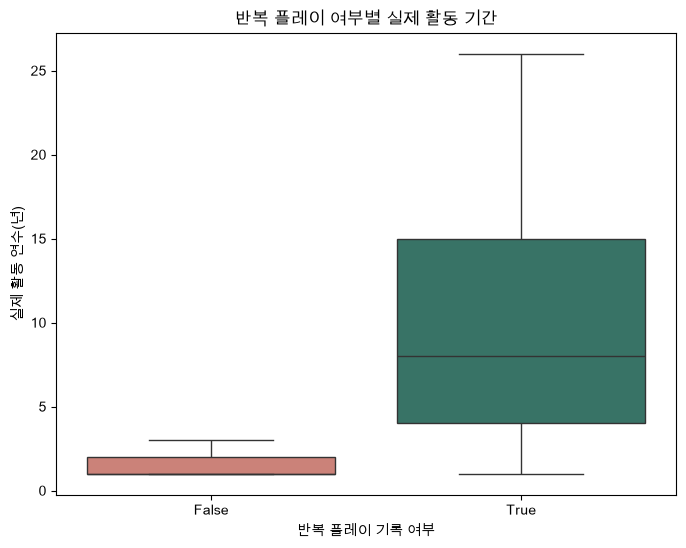

In [6]:
up = user_play.copy()
up["play_year"] = pd.to_datetime(up["play_date"]).dt.year
byu = up.groupby("user_id").agg(
    first_year=("play_year", "min"),
    last_year=("play_year", "max"),
    n_years_active=("play_year", "nunique"),
    n_plays=("play_date", "size"),
)
byu["recency_years"] = 2026 - byu["last_year"]

h1 = byu.merge(funnel_user.set_index("user_id")[["has_repeat_play_record"]], left_index=True, right_index=True, how="left")
h1 = h1.dropna(subset=["has_repeat_play_record"])

summary = h1.groupby("has_repeat_play_record").agg(
    n=("n_plays", "size"),
    활동연수_중앙값=("n_years_active", "median"),
    최근성_중앙값=("recency_years", "median"),
    총플레이_중앙값=("n_plays", "median"),
)
display(summary)

g1 = h1[h1.has_repeat_play_record]["n_years_active"]
g0 = h1[~h1.has_repeat_play_record]["n_years_active"]
u_stat, p = stats.mannwhitneyu(g1, g0, alternative="two-sided")
r = 1 - (2 * u_stat) / (len(g1) * len(g0))
print(f"활동 연수 Mann-Whitney: p={p:.2e}, rank-biserial r={r:.2f} (반복플레이 있음 n={len(g1)}, 없음 n={len(g0)})")

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=h1, x="has_repeat_play_record", y="n_years_active", showfliers=False,
            palette=["#D9776B", "#2E7D6B"], ax=ax)
ax.set_title("반복 플레이 여부별 실제 활동 기간")
ax.set_xlabel("반복 플레이 기록 여부")
ax.set_ylabel("실제 활동 연수(년)")
plt.show()

**결과**

- 반복 플레이한 유저(647명)는 실제 활동 연수 중앙값이 8년이고 2026년까지 활동이 이어지는 것으로 확인
- 없는 유저(82명)는 활동 연수 중앙값 1년, 마지막 활동이 7년 전으로 확인
    - 효과크기가 매우 큼(r≈-0.81)
- 이는 반복 플레이라는, 한 시점에 확인한 지표가 실제 장기 지속성과 강하게 연결된다는 것을 시사(상관 확인이지 인과 확인은 아님)
- 이 결과 위에서, 세그먼트도 실제 시간축에서 유지되는지 다음 절에서 확인한다


## 2. 세그먼트는 시간이 지나도 유지되는가

- [Segment 분석](03.Segment_Wishlist.ipynb)의 보유 게임 수×활용도 2×2 세그먼트는 카이제곱·비지도 군집화로 검증됐지만, 
- 전부 한 시점의 데이터로 한 검증이다. 
- 세그먼트별로 실제 플레이 로그의 활동 궤적을 비교해, 이 구분이 시간이 지나도 유지되는지 확인한다.

,인원,활동span_년,활동연수_중앙값,최근성_중앙값,총플레이_중앙값
segment5,,,,,
0.미플레이,28,0.0,1.0,8.5,1.0
1.몰입형,152,13.0,13.0,0.0,3287.5
2.수집가형,188,10.0,8.0,0.0,500.0
3.집중형,194,8.0,8.0,0.0,1158.0
4.저관여형,162,1.0,2.0,4.0,25.0


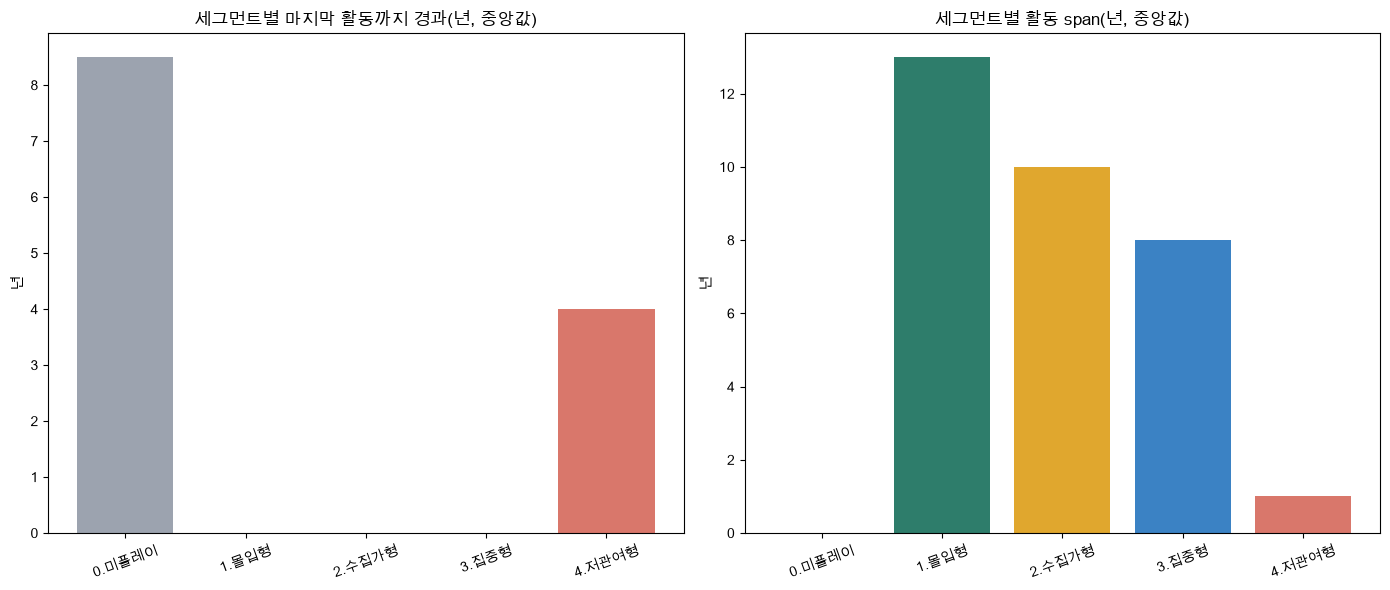

In [7]:
owners = funnel_user[funnel_user["is_owner"]].copy()
players = owners[owners["has_play_record"]].copy()
players = players.merge(user_info, on="user_id", how="left")
players["rating_ratio"] = players["n_rated"] / players["n_owned"]
play_ratio = funnel_item.groupby("user_id")["has_play_record"].mean().rename("play_game_ratio")
players = players.merge(play_ratio, on="user_id", how="left")

med_owned = players["n_owned"].median()
med_ratio = players["play_game_ratio"].median()
players["segment5"] = np.select(
    [
        (players["n_owned"] >= med_owned) & (players["play_game_ratio"] >= med_ratio),
        (players["n_owned"] >= med_owned) & (players["play_game_ratio"] < med_ratio),
        (players["n_owned"] < med_owned) & (players["play_game_ratio"] >= med_ratio),
    ],
    ["1.몰입형", "2.수집가형", "3.집중형"],
    default="4.저관여형",
)
owners["segment5"] = "0.미플레이"
for seg in PLAYER_ORDER:
    owners.loc[owners.user_id.isin(players[players.segment5 == seg].user_id), "segment5"] = seg

traj = byu.merge(owners.set_index("user_id")["segment5"], left_index=True, right_index=True, how="left")
n_no_segment = traj["segment5"].isna().sum()
if n_no_segment:
    print(f"실제 플레이 로그가 있지만 is_owner=False라 segment5가 없어 이 절에서 제외되는 유저: {n_no_segment}명")
traj = traj.dropna(subset=["segment5"])
traj["span_years"] = traj["last_year"] - traj["first_year"]

seg_summary = traj.groupby("segment5").agg(
    인원=("n_plays", "size"),
    활동span_년=("span_years", "median"),
    활동연수_중앙값=("n_years_active", "median"),
    최근성_중앙값=("recency_years", "median"),
    총플레이_중앙값=("n_plays", "median"),
).reindex(SEGMENT_ORDER)
display(seg_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rec = traj.groupby("segment5")["recency_years"].median().reindex(SEGMENT_ORDER)
axes[0].bar(rec.index, rec.values, color=[SEGMENT_COLORS[s] for s in SEGMENT_ORDER])
axes[0].set_title("세그먼트별 마지막 활동까지 경과(년, 중앙값)")
axes[0].set_ylabel("년")
axes[0].tick_params(axis="x", rotation=20)

span = traj.groupby("segment5")["span_years"].median().reindex(SEGMENT_ORDER)
axes[1].bar(span.index, span.values, color=[SEGMENT_COLORS[s] for s in SEGMENT_ORDER])
axes[1].set_title("세그먼트별 활동 span(년, 중앙값)")
axes[1].set_ylabel("년")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

**결과**

- 몰입형·수집가형·집중형은 2026년까지 활동이 이어지고(최근성 중앙값 0년), 활동 span도 8~13년으로 긴 것으로 확인
- 저관여형만 마지막 활동이 4~5년 전이고 활동 span도 1년뿐인 것으로 확인
- 세그먼트 구분 자체는 시간축에서도 유효하다는 것을 시사
    - 다만 반전이 하나 확인됨: [Segment 분석](03.Segment_Wishlist.ipynb)이 "착시 위험군"으로 지목한 수집가형은 시간축으로 보면 몰입형·집중형과 마찬가지로 여전히 활동 중
    - 실제로 재참여가 끊긴 건 [Segment 분석](03.Segment_Wishlist.ipynb)에서 마지막 로그인이 가장 오래된 것으로 확인됐던 저관여형으로 확인
    - 세그먼트 구분은 유효하지만, 어느 세그먼트가 "위험"인지는 한 시점 데이터로 봤을 때의 판단과 다르게 나온다는 것을 시사


### 2-1. K-means 활동축은 실제 궤적과 일치하는가

- [Segment 분석](03.Segment_Wishlist.ipynb)의 비지도 군집화는 세그먼트 정의에 안 쓴 축(로그인 경과일)으로 갈리는 네 번째 군집을 탐색적으로 찾아냈다. 
- 그 군집이 실제 플레이 로그의 최근성과 일치하는지 같은 파라미터로 재현해 확인한다.

In [8]:
players["log_owned"] = np.log1p(players["n_owned"])
players["days_since_login"] = (pd.Timestamp("2026-09-07") - pd.to_datetime(players["lastlogin"], errors="coerce")).dt.days
players["log_dsl"] = np.log1p(players["days_since_login"].fillna(players["days_since_login"].median()))

feat_cols = ["log_owned", "play_game_ratio", "rating_ratio", "log_dsl"]
X = players[feat_cols].fillna(players[feat_cols].median())
X_scaled = StandardScaler().fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_scaled)
players["kmeans_cluster"] = kmeans.labels_

players = players.merge(byu["recency_years"], left_on="user_id", right_index=True, how="left")

cluster_summary = players.groupby("kmeans_cluster").agg(
    인원=("user_id", "size"),
    로그인경과일_중앙값=("days_since_login", "median"),
    실로그보유율=("recency_years", lambda s: s.notna().mean()),
    실제최근성_중앙값=("recency_years", "median"),
)
display(cluster_summary.round(2))

sub = players.dropna(subset=["recency_years"])
rho, p = stats.spearmanr(sub["days_since_login"], sub["recency_years"])
print(f"스피어만(로그인 경과일, 실제 플레이로그 최근성): rho={rho:.3f}, p={p:.2e}, n={len(sub)}")

,인원,로그인경과일_중앙값,실로그보유율,실제최근성_중앙값
kmeans_cluster,,,,
0,678,6.0,0.34,0.0
1,643,6.0,0.35,0.0
2,295,596.0,0.36,6.0
3,372,6.0,0.37,3.0


스피어만(로그인 경과일, 실제 플레이로그 최근성): rho=0.485, p=2.16e-42, n=696


**결과**

- 로그인 경과일 중앙값이 유독 높은 군집(약 600일)의 실제 플레이 로그 최근성 중앙값도 6년으로 확인
    - 다른 세 군집(0~3년)보다 뚜렷이 높음
    - 로그인 경과일과 실제 최근성의 스피어만 상관은 0.49(p<0.001)로 중간 수준의 관계로 확인
- 탐색적 발견이 실제 시간 정보를 담고 있었다는 두 번째 독립 근거로 확인
- 로그인 경과일은 완벽하지는 않지만 실제 참여 지속성의 쓸 만한 대리 지표로 관찰된다


### 2-2. 미플레이 라벨, 얼마나 믿을 수 있는가

- `has_play_record`(미플레이 판정 기준)는 자기입력값인 `numplays`로 정의된다 — 기록이 없는 게 "안 한 것"인지 "안 남긴 것"인지는 이 값만으로 구분할 수 없다([data_model.md](../docs/data_model.md)에 이미 명시된 한계).
- 위 `traj`에는 이미 실제 플레이 로그 수집 대상(`plays_sample`, 1,065명)과 미플레이 라벨(956명)이 겹치는 유저가 섞여 있다 — 이 교집합으로 라벨의 오탐률을 직접 추정한다.


In [9]:
owners["rating_ratio"] = owners["n_rated"] / owners["n_owned"]

nonplayers = owners[owners["segment5"] == "0.미플레이"].copy()
validatable = nonplayers[nonplayers["user_id"].isin(plays_sample["user_id"])].copy()
validatable["has_real_log"] = validatable["user_id"].isin(byu.index)

n_val = len(validatable)
n_mislabel = int(validatable["has_real_log"].sum())
rate = n_mislabel / n_val
ci_low, ci_high = proportion_confint(n_mislabel, n_val, method="wilson")
print(f"미플레이 라벨 {len(nonplayers)}명 중 검증 가능 표본(plays_sample 교집합) {n_val}명")
print(f"실제 로그 있음(오탐 추정): {n_mislabel}명 ({rate:.1%}, 95% Wilson CI [{ci_low:.1%}, {ci_high:.1%}])")

g1 = validatable[validatable.has_real_log]["rating_ratio"]
g0 = validatable[~validatable.has_real_log]["rating_ratio"]
u_stat, p = stats.mannwhitneyu(g1, g0, alternative="two-sided")
r = 1 - (2 * u_stat) / (len(g1) * len(g0))
print(f"\nrating_ratio 중앙값: 오탐 추정군={g1.median():.2f}(n={len(g1)}), 진짜 미플레이 추정군={g0.median():.2f}(n={len(g0)})")
print(f"Mann-Whitney: p={p:.3f}, rank-biserial r={r:.2f}")


미플레이 라벨 956명 중 검증 가능 표본(plays_sample 교집합) 340명
실제 로그 있음(오탐 추정): 28명 (8.2%, 95% Wilson CI [5.8%, 11.6%])

rating_ratio 중앙값: 오탐 추정군=0.73(n=28), 진짜 미플레이 추정군=0.85(n=312)
Mann-Whitney: p=0.068, rank-biserial r=0.21


**결과**

- 미플레이 라벨 956명 중 실제 로그 수집 대상과 겹치는 340명을 검증 가능 표본으로 확인
- 그중 28명(8.2%, 95% CI 5.8~11.6%)은 실제 플레이 로그가 있는 것으로 확인 — 최소 이 비율만큼은 "안 한 사람"이 아니라 "기록만 안 한 사람"으로 추정
    - 로그 미수집 유저까지 포함하면 이 비율이 더 클 수도, 검증 표본 자체가 BGG 로그 기능을 쓰는 유저층에 치우쳤다면 방향이 달라질 수도 있음 — 하한 추정으로만 읽는다
- "평가를 많이 할수록 오분류 가능성이 높다"는 가설을 이 표본으로 직접 확인: 오탐 추정군의 rating_ratio 중앙값(0.73, n=28)이 진짜 미플레이 추정군(0.85, n=312)보다 오히려 낮음(Mann-Whitney p=0.068, r=0.21)
    - n=28로는 검정력이 낮아 유의하다고 말하기 어렵고 방향도 가설과 반대라, 이 표본만으로는 가설을 뒷받침도 기각도 하기 어려움 — 판단 보류
- 그럼에도 8.2%는 퍼널 최대 손실 구간(-32.5%p, 956명)을 뒤집을 정도는 아니며, 미플레이 세그먼트의 존재 자체는 유지. 다만 정확한 인원(956명)은 자기입력값 기반 추정치로 이해해야 함


### 2-3. 쉬는 기간이 길어질수록 다시 돌아올 확률은 얼마나 낮아지는가

- 재참여 메일을 언제, 누구에게 보낼지 정하려면, 얼마나 쉬었을 때 다시 돌아오는지를 알아야 한다.
- 플레이 로그에는 일 단위 날짜가 있어서, "X일 쉬었을 때 그 뒤 30일 안에 다시 기록이 생긴 비율"을 X별로 계산한다.
- 로그가 있는 전체 유저(729명)와, 총 플레이 100회 이하 유저를 저관여형 대용으로 나눠 함께 본다(저관여형의 총 플레이 중앙값이 25회로 확인됐기 때문).
- 마지막 접속일(`lastlogin`)로는 전체 유저가 지금 얼마나 오래 쉬고 있는지도 확인한다.


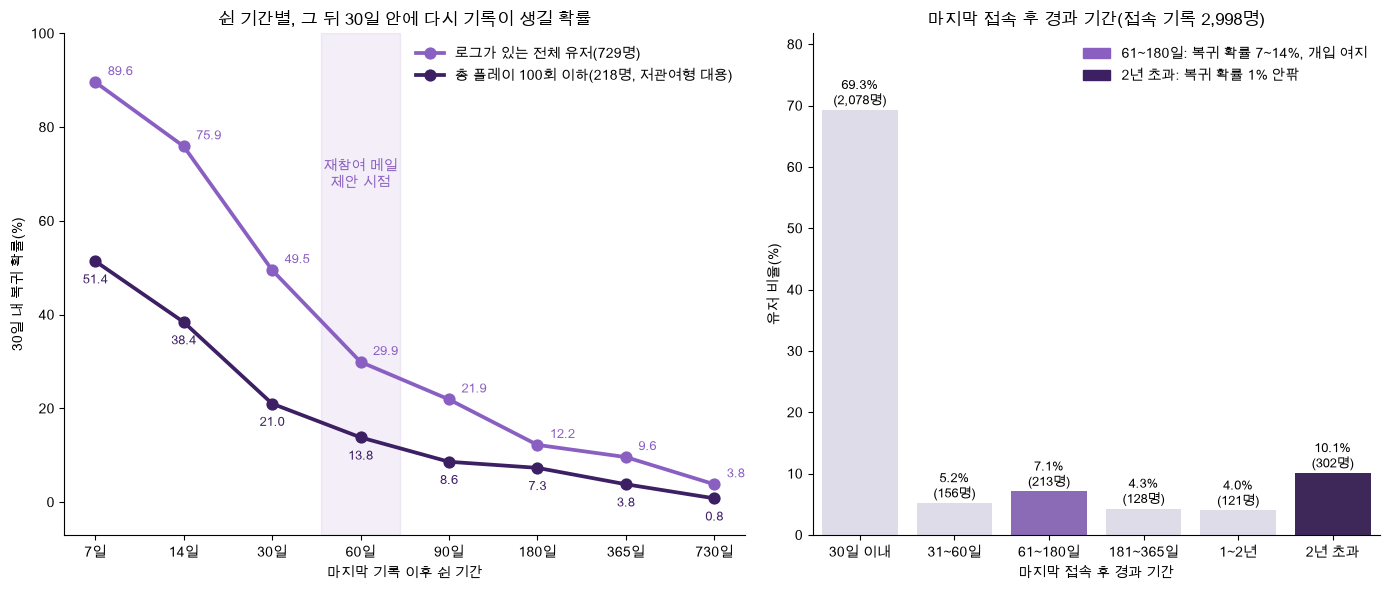

In [ ]:
from matplotlib.patches import Patch

# 관측 종료일: 이 노트북 전체에서 쓰는 기준일(2-1과 동일)
END = pd.Timestamp("2026-09-07")

# 유저별 플레이 날짜(하루에 여러 번 기록해도 1일). END 기준 며칠 전인지(0 이하)로 저장
day_no = (pd.to_datetime(user_play["play_date"]) - END).dt.days
play_days = {u: np.sort(g.unique()) for u, g in day_no.groupby(user_play["user_id"])}
n_records = user_play.groupby("user_id").size()


def return_prob(users, thresholds=(7, 14, 30, 60, 90, 180, 365, 730)):
    """X일 쉬었을 때, 그 뒤 30일 안에 다시 플레이 기록이 생긴 비율"""
    closed, still_open = [], []
    for u in users:
        d = play_days[u]
        closed += list(np.diff(d))        # 기록과 기록 사이에 쉰 기간
        still_open.append(-d[-1])         # 마지막 기록 이후 지금까지 쉰 기간
    closed, still_open = np.array(closed), np.array(still_open)
    rows = []
    for x in thresholds:
        back = ((closed >= x) & (closed < x + 30)).sum()
        # 아직 안 돌아온 경우는 X+30일 이상 지켜본 것만 센다(관측이 짧아 알 수 없는 건 제외)
        not_back = (closed >= x + 30).sum() + (still_open >= x + 30).sum()
        rows.append({"쉰 기간": f"{x}일", "복귀(%)": round(back / (back + not_back) * 100, 1)})
    return pd.DataFrame(rows)


all_users = list(play_days)
light_users = [u for u in all_users if n_records[u] <= 100]   # 저관여형 대용(저관여형 총 플레이 중앙값 25회)
g_all = f"로그가 있는 전체 유저({len(all_users)}명)"
g_light = f"총 플레이 100회 이하({len(light_users)}명, 저관여형 대용)"
curve = pd.concat([return_prob(all_users).assign(집단=g_all), return_prob(light_users).assign(집단=g_light)])

# 마지막 접속일 기준: 전체 유저가 얼마나 오래 쉬고 있는가
idle_days = (END - pd.to_datetime(user_info["lastlogin"], errors="coerce")).dt.days.dropna()
idle = (pd.cut(idle_days, [-1, 30, 60, 180, 365, 730, np.inf],
               labels=["30일 이내", "31~60일", "61~180일", "181~365일", "1~2년", "2년 초과"])
        .value_counts().sort_index().rename_axis("구간").reset_index(name="인원"))
idle["구간"] = idle["구간"].astype(str)
idle["비율(%)"] = (idle["인원"] / idle["인원"].sum() * 100).round(1)

PURPLE_DARK, PURPLE_MID, PURPLE_LIGHT = "#3D1F63", "#8A5FC2", "#DCDAEB"
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.2, 1]})

# 왼쪽: 쉰 기간별 30일 내 복귀 확률
ax = axes[0]
palette = {g_all: PURPLE_MID, g_light: PURPLE_DARK}
sns.pointplot(data=curve, x="쉰 기간", y="복귀(%)", hue="집단", palette=palette, errorbar=None,
              markers="o", linestyles="-", ax=ax)
ax.axvspan(2.55, 3.45, color=PURPLE_MID, alpha=0.10, zorder=0)   # 60일 구간 강조
ax.text(3, 70, "재참여 메일\n제안 시점", color=PURPLE_MID, fontsize=10, ha="center", va="center")
for g, (dx, dy, ha) in [(g_all, (9, 5, "left")), (g_light, (0, -16, "center"))]:
    for i, v in enumerate(curve.loc[curve["집단"] == g, "복귀(%)"]):
        ax.annotate(f"{v:.1f}", (i, v), textcoords="offset points", xytext=(dx, dy),
                    ha=ha, fontsize=9, color=palette[g])
ax.set_ylim(-7, 100)
ax.set_title("쉰 기간별, 그 뒤 30일 안에 다시 기록이 생길 확률")
ax.set_xlabel("마지막 기록 이후 쉰 기간")
ax.set_ylabel("30일 내 복귀 확률(%)")
ax.legend(title=None, frameon=False, loc="upper right")

# 오른쪽: 마지막 접속 후 경과 기간 분포
ax = axes[1]
bar_colors = dict(zip(idle["구간"], [PURPLE_LIGHT, PURPLE_LIGHT, PURPLE_MID, PURPLE_LIGHT, PURPLE_LIGHT, PURPLE_DARK]))
sns.barplot(data=idle, x="구간", y="비율(%)", hue="구간", palette=bar_colors, legend=False, ax=ax)
for i, r in idle.iterrows():
    ax.annotate(f"{r['비율(%)']:.1f}%\n({r['인원']:,}명)", (i, r["비율(%)"]), textcoords="offset points",
                xytext=(0, 4), ha="center", fontsize=9)
ax.set_ylim(0, idle["비율(%)"].max() * 1.18)
ax.set_title(f"마지막 접속 후 경과 기간(접속 기록 {len(idle_days):,}명)")
ax.set_xlabel("마지막 접속 후 경과 기간")
ax.set_ylabel("유저 비율(%)")
ax.legend(handles=[Patch(color=PURPLE_MID, label="61~180일: 복귀 확률 7~14%, 개입 여지"),
                   Patch(color=PURPLE_DARK, label="2년 초과: 복귀 확률 1% 안팎")],
          frameon=False, loc="upper right")

sns.despine(fig)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "assets" / "return_prob.png", dpi=150, bbox_inches="tight")
plt.show()

**결과**

- 마지막 접속 기준으로 접속 기록이 있는 2,998명 중 69.3%는 최근 30일 안에 활동한 것으로 확인
    - 2년을 넘게 접속하지 않은 유저가 10.1%(302명)로, 오래 쉬는 유저 중 가장 큰 덩어리로 확인
- 쉬는 기간이 길수록 그 뒤 30일 안에 다시 기록을 남길 확률이 뚜렷하게 낮아지는 것으로 확인
    - 저관여형 대용(218명)은 30일 쉰 시점 21.0%, 60일 13.8%, 90일 8.6%, 2년 0.8%
    - 로그가 있는 전체 유저(729명)는 같은 시점에 각각 49.5%, 29.9%, 21.9%, 3.8%
- 2년 넘게 쉰 유저는 아무 개입이 없으면 돌아올 확률이 1% 안팎이라, 오래전에 떠난 유저를 부르는 캠페인은 효율이 낮을 가능성을 시사
- 반면 접속 기준 61~180일 쉬는 유저는 213명(7.1%)이고, 같은 구간의 복귀 확률이 7~14%(저관여형 대용)로 남아 있어 떠나는 중인 이 구간이 개입 여지가 더 큰 것으로 확인
- 다만 이 값은 아무 개입 없이 저절로 돌아오는 비율이라 재참여 메일의 효과를 뜻하지 않음
    - 실험에서 메일을 받지 않은 그룹이 보일 기준값과, 메일을 보낼 시점을 정하는 참고로만 사용
- 로그를 남기는 유저층에 치우친 표본이고, 접속 기준과 플레이 기준이 다르며, 나중에 몰아서 입력한 기록이 섞였을 수 있는 점은 한계로 남음


## 3. 최근에 가입한 유저일수록 실제로 게임을 해서 기록을 덜 남기는가

- [EDA](01.EDA.ipynb) 1-4는 가입연도 흐름에 정체와 2021년 급감 구간이 있다는 걸 확인했지만, 
- 이게 "가입만 줄어든 것"인지 "가입은 했는데 실제 참여로 이어지지 않는 비율이 늘어난 것"인지는 보지 않았다. 
- 구매(보유) 이후 실제 플레이로 이어지는 비율이 최근 가입자일수록 낮은지 확인하는, 이 프로젝트의 핵심 질문이라 여기서 확인한다.

,인원,실로그_보유율
cohort_bin,,
~2005,186,0.854839
2006-10,215,0.744186
2011-15,215,0.693023
2016-20,215,0.702326
2021+,234,0.470085



참고: 로그 있는 유저 중 최근 2년 내 활동 비율(관찰 기간이 짧은 최근 코호트에 유리한 편향 있음)
cohort_bin
~2005      0.597484
2006-10    0.531250
2011-15    0.671141
2016-20    0.748344
2021+      0.909091
Name: recency_years, dtype: float64


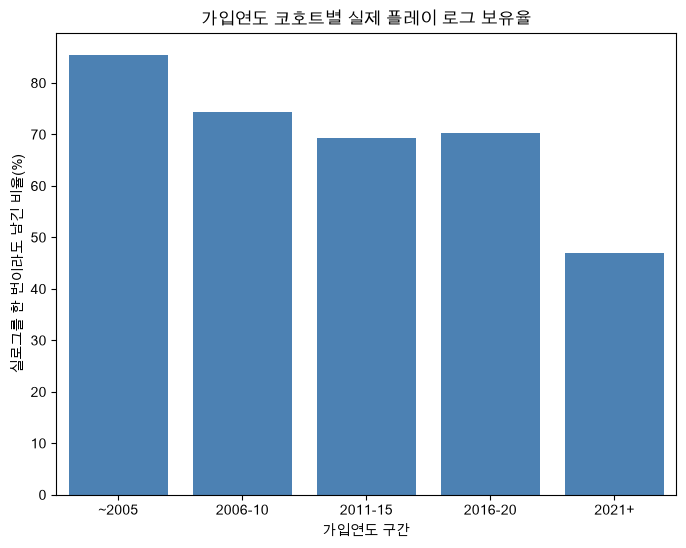

In [10]:
ps = plays_sample.copy()
ps["cohort_bin"] = pd.cut(ps["yearregistered"], [1998, 2005, 2010, 2015, 2020, 2027],
                           labels=["~2005", "2006-10", "2011-15", "2016-20", "2021+"])
ps["has_log"] = ps["user_id"].isin(byu.index)

cohort_summary = ps.groupby("cohort_bin", observed=True).agg(
    인원=("user_id", "size"),
    실로그_보유율=("has_log", "mean"),
)
display(cohort_summary)

# 참고 지표: 로그가 있는 사람 중 최근 2년 내 활동 비율(관찰 기간 편향 있음, 참고만)
ps_log = ps[ps.has_log].merge(byu["recency_years"], left_on="user_id", right_index=True, how="left")
recent_rate = ps_log.groupby("cohort_bin", observed=True)["recency_years"].apply(lambda s: (s <= 2).mean())
print("\n참고: 로그 있는 유저 중 최근 2년 내 활동 비율(관찰 기간이 짧은 최근 코호트에 유리한 편향 있음)")
print(recent_rate)

plt.figure(figsize=(8, 6))
sns.barplot(x=cohort_summary.index, y=cohort_summary["실로그_보유율"] * 100, color="#3B82C4")
plt.title("가입연도 코호트별 실제 플레이 로그 보유율")
plt.xlabel("가입연도 구간")
plt.ylabel("실로그를 한 번이라도 남긴 비율(%)")
plt.show()

**결과**

- 실제 플레이 로그를 한 번이라도 남긴 비율이 ~2005년 가입 코호트 85.5%에서 2021년 이후 가입 코호트 47.0%까지 떨어지는 것으로 확인
- "최근 2년 내 활동 비율"은 최근 코호트일수록 오히려 높게 나오는 것으로 확인
    - 이는 관찰 기간 자체가 짧아 유리해지는 편향이라 그대로 해석하지 않는다
- 최근 가입 코호트일수록 "가입"에서 "실제로 게임을 해서 기록을 남기는 것"까지 이어지는 비율 자체가 낮아진다는 것을 시사
    - [Funnel 분석](02.Funnel.ipynb)이 확인한 보유→플레이 감소(-32.5%p)가 고정된 상수가 아니라 최근으로 갈수록 더 벌어지고 있을 가능성을 시사
    - 코호트당 표본이 150~230명 수준이라 방향성으로 읽는다

- 다만 이 비교는 코호트마다 관측 가능 기간이 최대 4배(2021+ 최대 5년 vs ~2005 최대 20년) 차이 나 불공정하다는 지적(서면 피드백)이 있어, 바로 아래에서 기간을 통제해 다시 비교한다


### 3-1. 공정 비교 — 가입 후 N년 이내 기록 보유율

- 위 결과는 오래된 코호트일수록 관측 가능 기간이 길다는 문제가 있다(~2005 코호트는 최대 20년, 2021+ 코호트는 최대 5년 관측 가능).
- `yearregistered`가 연 단위(월/일 없음, [data_model.md](../docs/data_model.md))라 일 단위 정규화는 불가능하지만, "가입 후 N년 이내" 기준의 연 단위 공정 비교는 가능하다.
- 모든 코호트가 N년을 온전히 채운 경우만 비교 대상에 포함(예: N=5면 가입 후 5년이 안 지난 유저는 그 코호트에서 제외) — 이렇게 하지 않으면 최근 코호트가 "아직 N년이 안 지나서" 낮게 나오는 착시가 그대로 남는다.
- N=1(표본 손실 최소, 서면 피드백 예시와 동일)과 N=5(가장 엄격한 비교, 2021+는 순수 2021년 가입자로 좁혀져 표본이 43명으로 줄어듦)를 병기한다.


=== 가입 후 1년 이내 기록 보유율 ===


,인원,기록보유율
cohort_bin,,
~2005,186,0.430108
2006-10,215,0.483721
2011-15,215,0.418605
2016-20,215,0.465116
2021+,215,0.432558


카이제곱: chi2=2.56, p=0.6348, Cramer's V=0.049

=== 가입 후 5년 이내 기록 보유율 ===


,인원,기록보유율
cohort_bin,,
~2005,186,0.736559
2006-10,215,0.613953
2011-15,215,0.576744
2016-20,215,0.674419
2021+,43,0.651163


카이제곱: chi2=12.93, p=0.0116, Cramer's V=0.122



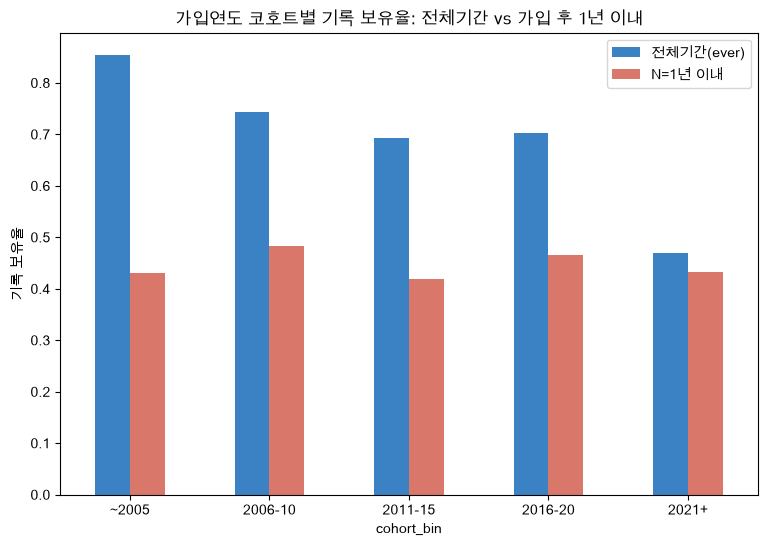

In [11]:
CURRENT_YEAR = 2026
ps["years_elapsed"] = CURRENT_YEAR - ps["yearregistered"]
merged_offset = up.merge(ps[["user_id", "yearregistered", "cohort_bin"]], on="user_id", how="inner")
merged_offset["year_offset"] = merged_offset["play_year"] - merged_offset["yearregistered"]

def fair_window_summary(n):
    eligible = ps[ps["years_elapsed"] >= n].copy()
    active_ids = merged_offset[(merged_offset["year_offset"] >= 0) & (merged_offset["year_offset"] <= n)]["user_id"].unique()
    eligible["has_log_within_n"] = eligible["user_id"].isin(active_ids)
    tbl = eligible.groupby("cohort_bin", observed=True)["has_log_within_n"].agg(인원="size", 기록보유율="mean")
    ct = pd.crosstab(eligible["cohort_bin"], eligible["has_log_within_n"])
    try:
        # crosstab이 1차원(범주가 1개뿐)이면 ValueError — src/preprocess/eda.py의
        # check_chi2_test와 동일한 가드(표본이 작은 코호트에서 실제로 발생 가능).
        chi2, p, dof, exp = stats.chi2_contingency(ct)
        cramers_v = (chi2 / (ct.values.sum() * (min(ct.shape) - 1))) ** 0.5
    except ValueError as e:
        print(f"N={n} 카이제곱 검정 실패(표본이 한쪽으로 쏠림): {e}")
        chi2, p, cramers_v = np.nan, np.nan, np.nan
    return tbl, chi2, p, cramers_v

fair_tables = {}
for n in [1, 5]:
    tbl, chi2, p, v = fair_window_summary(n)
    fair_tables[n] = tbl
    print(f"=== 가입 후 {n}년 이내 기록 보유율 ===")
    display(tbl)
    print(f"카이제곱: chi2={chi2:.2f}, p={p:.4f}, Cramer's V={v:.3f}\n")

compare_tbl = cohort_summary[["인원", "실로그_보유율"]].rename(columns={"실로그_보유율": "전체기간(ever)"})
compare_tbl["N=1년 이내"] = fair_tables[1]["기록보유율"]
fig, ax = plt.subplots(figsize=(13, 4.8))
compare_tbl[["전체기간(ever)", "N=1년 이내"]].plot(kind="bar", ax=ax, color=["#8A5FC2", "#3D1F63"])
ax.set_title("가입연도 코호트별 기록 보유율: 전체기간 vs 가입 후 1년 이내")
ax.set_ylabel("기록 보유율")
plt.xticks(rotation=0)
plt.savefig(PROJECT_ROOT / "assets" / "cohort_retention.png", dpi=150, bbox_inches="tight")
plt.show()


**결과**

- 가입 후 1년 이내 기록 보유율은 43.0%~48.4%로 코호트 간 차이가 거의 없는 것으로 확인(카이제곱 p=0.635, Cramer's V=0.049로 사실상 무관)
- 가입 후 5년 이내 기록 보유율은 코호트 간 차이가 통계적으로 유의하지만(카이제곱 p=0.012) 효과크기는 작고(Cramer's V=0.122), 2021+ 코호트(65.1%, n=43)가 2006-10(61.4%)·2011-15(57.7%) 코호트보다 오히려 높아 "최근일수록 낮다"는 단조 추세와 다른 것으로 확인
- 전체기간(ever) 기준의 85.5%→47.0%라는 뚜렷한 하락은 코호트마다 관측 기간이 최대 4배 차이 나는 데서 오는 편향으로 판단됨 — 기간을 공정하게 맞추면 그 추세가 거의 사라지거나(N=1) 작고 일관되지 않은 차이(N=5)로 줄어듦
- N=5의 2021+ 코호트는 순수 2021년 가입자 43명뿐이라 표본이 작다는 한계는 남음


## 4. 결론

- H1(반복 플레이와 실제 지속 활동의 관계): 채택
    - 같은 게임을 두 번 이상 한 기록이 있으면, 실제로도 활동을 오래 이어가는 것으로 확인
- H2(유형 구분이 시간이 지나도 유지되는가): 부분 채택
    - 유형 구분 자체는 시간이 지나도 유효하지만, 어느 쪽이 위험한지는 다시 잡아야 함
    - 수집가형이 아니라 저관여형이 실제로 몇 년째 돌아오지 않은 집단으로 확인
    - 군집화가 찾아낸 시간 축도 실제 활동 최근성과 어느 정도 같은 방향(상관 0.49)이라 이 결론을 뒷받침
- H3(최근 가입자의 기록 남김 비율): 기각
    - 전체기간(ever) 기준으로는 85.5%→47.0%로 뚜렷한 하락처럼 보였지만, 코호트별 관측 기간(최대 20년 vs 5년) 차이를 공정하게 통제하면(가입 후 N년 이내 기준) 그 추세가 거의 사라지거나(N=1, 카이제곱 p=0.635) 작고 비단조적인 차이(N=5, Cramer's V=0.122)로 줄어듦
    - 기존 관측은 관측 기간 편향의 산물로 판단, "최근 가입자일수록 정착에 실패하는 추세"라는 인과적 해석은 근거 부족

H2에서는 예상이 뒤집혔다. [Segment 분석](03.Segment_Wishlist.ipynb)까지는 "많이 갖고 안 쓰는" 수집가형을 위험군으로 봤는데, 실제 활동 기록을 열어보니 수집가형은 지금도 꾸준히 활동 중이었다. 정작 몇 년째 돌아오지 않은 쪽은 적게 갖고 그마저도 안 쓰던 저관여형이었다. 한 시점의 데이터만 봤다면 엉뚱한 집단에 재활성화 캠페인을 돌렸을 것이다.


## 5. 프로젝트 종합

- 목표(보유한 보드게임을 실제 플레이로 이어지게 하려면 어디에 개입해야 하는지, 유저 행동 데이터로 근거를 남기는 것)로 돌아가 정리한다.

### 5-1. 핵심 인사이트

- 유저를 가장 많이 잃는 순간은 게임을 산 뒤 플레이하기까지다([Funnel 분석](02.Funnel.ipynb))
    - 다만 이 손실이 최근 가입자일수록 더 커지는 추세인지는 이 데이터로 확정하기 어려움(H3, 3-1) — 가입 후 1년 이내 기록 보유율은 코호트 간 43~48%로 고르게 낮은 수준
- 같은 게임을 두 번 이상 반복 플레이했다는 사실 하나가, 그 사람이 앞으로 몇 년을 더 활동할지와 강하게 연결돼 있다(H1)
    - 한 시점 데이터만 보고 내린 판단이 근거 없는 추측은 아니었다는 뜻이다
- 많이 가진 유저가 잘 쓰는 유저는 아니다
    - 비율 지표, 군집화, 실제 활동 기록이라는 서로 다른 세 방향에서 같은 결론이 나왔다(H2)
- 진짜 위험한 쪽은 많이 갖고 안 쓰는 사람이 아니라, 적게 갖고도 몇 년째 돌아오지 않는 사람이다(H2)
- 평가만 하고 플레이는 하지 않는 층이 실제로 존재하고, 위시리스트는 곧 살 것의 예고가 아니라 관심 표시에 가깝다([Segment 분석](03.Segment_Wishlist.ipynb))

### 5-2. 그로스 전략 제안

> 아래 액션은 위 인사이트에서 나온 제안.  
> 데이터가 원인을 증명한 것은 아니라서, 해보고 확인할 방법을 함께 기재.

**확인 원칙**
- 한 번에 한 가지만 바꿔서 비교
- 핵심 지표는 "플레이 기록을 남긴 비율"로 통일하고, 부작용(예: 메일 수신거부)도 항목마다 함께 확인
- 필요한 인원을 미리 정하고, 결과를 보고 중간에 멈추지 않음

**순위 기준**
- 영향 크기, 근거 강도, 실행 난이도를 함께 판단. 5~6번은 근거가 약하거나 백로그를 키울 수 있어 후순위

| 순위 | 대상 | 제안 액션 | 근거 | 확인 방법 |
|:---:|---|---|---|---|
| 1 | 가입했거나 게임을 처음 등록한 직후 유저 | "첫 플레이 기록" 배지 주기<br>기록이 없으면 안내 메일 1통 | 가장 많이 빠지는 구간이 보유 → 플레이(-32.5%p, 956명)<br>가입 후 1년 안 기록 비율이 가입 시기 간 차이가 거의 없이 43~48%(3-1) | 배지와 메일을 각각 따로, 본 그룹 vs 못 본 그룹 비교(A/B 테스트)<br>핵심: 첫 기록 남긴 비율<br>부작용: 메일 수신거부, 배지만 노린 가짜 기록 |
| 2 | 평점은 남겼지만 플레이 기록이 없는 유저 | 평점 남긴 직후 "플레이 기록도 남겨보세요" 안내 | 기록 없는 956명 중 99%가 평점은 남김([Segment 분석](03.Segment_Wishlist.ipynb) 2-0)<br>최소 8.2%는 했는데 기록만 안 남긴 것으로 추정(2-2) | 안내를 본 그룹 vs 못 본 그룹 비교<br>핵심: 안내 뒤 기록 남긴 비율<br>부작용: 평점 입력을 중간에 그만두는 비율 |
| 3 | 수집가형(많이 갖고 일부만 함, 지금도 활동 중) | 안 해본 보유 게임 중 자주 하는 게임과 비슷한 것(난이도·인원·시간)을 "다음에 할 게임"으로 추천 | 로그가 있는 수집가형 188명은 중앙값 기준 올해도 활동 중, 활동 기간 10년(2절)<br>무엇을 할지 고르기가 걸림돌이라는 가설 | 먼저 과거 기록으로 추천이 맞았는지 확인, 이후 A/B 테스트<br>핵심: 추천 게임을 플레이한 비율<br>부작용: 추천 끄기·숨기기 비율 |
| 4 | 기록이 끊긴 유저(저관여형과 같은 패턴) | 마지막 기록 60일 뒤부터 메일 3통(안부, 취향 맞춤 소개, 마지막 안내)<br>이미 4~5년 떠난 유저는 소규모로 반응부터 확인 | 저관여형은 약 1년만 활동하고 4~5년째 떠나 있음(2절)<br>2년 넘게 쉰 유저가 저절로 돌아올 확률은 1% 안팎, 60일 무렵은 10%대(2-3) | 메일 받은 그룹 vs 안 받은 그룹 비교<br>핵심: 30일 안에 다시 기록 남긴 비율<br>부작용: 수신거부, 스팸 신고 |
| 5 | 집중형(후순위) | 위시리스트와 비슷한 난이도 추천 vs 지금 하는 게임과 비슷한 난이도 추천, 두 가지 비교 | 원하는 게임과 실제 하는 게임의 난이도 차이가 가장 큼(0.26), 이유는 알 수 없음([Segment 분석](03.Segment_Wishlist.ipynb) 4-1) | 핵심: 추천 후 플레이 기록 남긴 비율<br>부작용: 게임 수만 늘고 플레이는 그대로인 경우 |
| 6 | 몰입형(후순위) | 보유 게임의 확장판·후속작 추천 | 몰입형만 선호 4~5위권에 확장판이 나타남, 가진 게임 계열을 반복해서 플레이([Segment 분석](03.Segment_Wishlist.ipynb) 3-2) | 핵심: 추천으로 산 게임을 플레이한 비율<br>부작용: 게임 수만 늘고 플레이는 그대로인 경우 |

> - 확인 기간은 소규모 시범 운영 뒤에 정함(안내를 받고 얼마 만에 반응하는지는 이 데이터에 없음)
> - 4번의 60일·30일은 쉬는 기간별 복귀 확률을 근거로 함(2-3)
> - 필요 인원은 기준값을 잰 뒤 계산(예: 4번은 13.8%→20.7%로 올리려면 그룹당 약 470명)
> - 이 프로젝트가 다룬 건 이미 가입해서 게임을 보유한 사람들의 행동뿐이라, 신규 유입을 늘리는 액션은 이 데이터로 증명 불가
> - "가입 후 며칠", "등록 후 며칠" 기준은 이 데이터로 알 수 없어(가입 연도만 제공, 게임 등록일 없음) 실험 전에 먼저 측정 필요
